========== STUDENT PERFORMANCE DATASET ==========
   Student_ID  Study_Hours  Attendance  Assignments  Marks
0         101            2          60            3     45
1         102            3          65            4     50
2         103            4          70            5     55
3         104            5          75            5     60
4         105            6          80            6     65

Dataset Shape: (20, 5)

Dataset Statistics:
       Student_ID  Study_Hours  Attendance  Assignments      Marks
count    20.00000    20.000000    20.00000    20.000000  20.000000
mean    110.50000     7.000000    83.25000     6.900000  73.200000
std       5.91608     2.991215    11.75126     2.149663  16.656277
min     101.00000     2.000000    60.00000     3.000000  45.000000
25%     105.75000     4.750000    74.25000     5.000000  59.500000
50%     110.50000     7.000000    85.50000     7.000000  73.500000
75%     115.25000     9.250000    92.50000     8.250000  87.000000
max     120.000

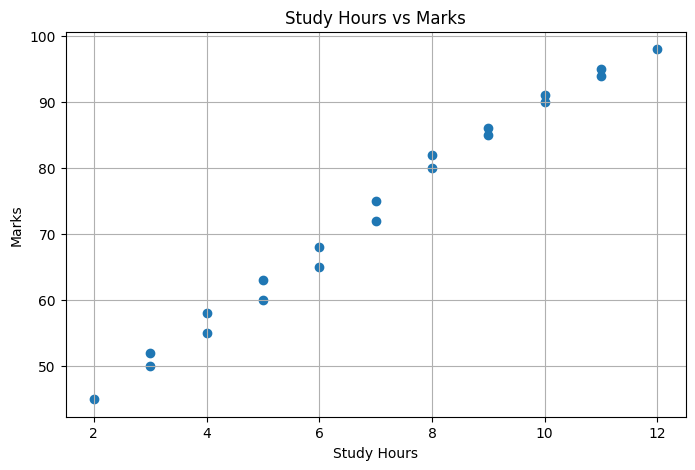

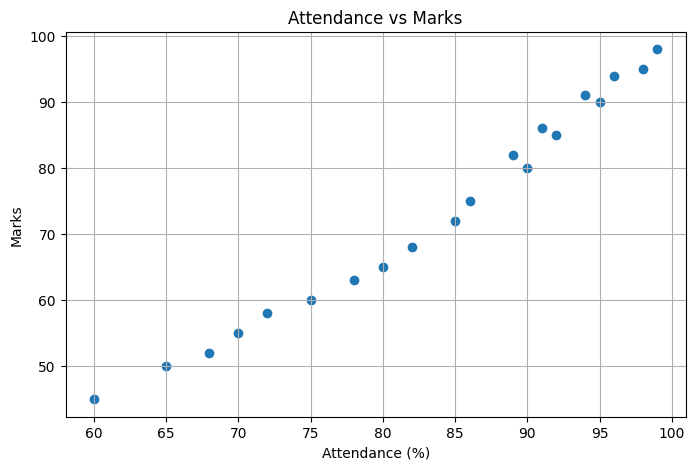

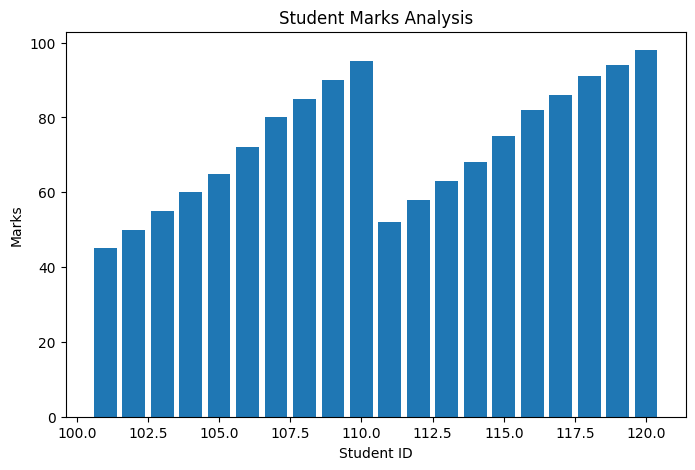


========== TOP 5 STUDENTS ==========
    Student_ID  Marks
19         120     98
9          110     95
18         119     94
17         118     91
8          109     90

========== OVERALL STATISTICS ==========
Average Study Hours: 7.0
Average Attendance: 83.25
Average Marks: 73.2

Project Completed Successfully


In [1]:
# STUDENT PERFORMANCE TRACKER USING MACHINE LEARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Student Dataset
data = {
    'Student_ID': [101,102,103,104,105,106,107,108,109,110,
                   111,112,113,114,115,116,117,118,119,120],

    'Study_Hours': [2,3,4,5,6,7,8,9,10,11,
                    3,4,5,6,7,8,9,10,11,12],

    'Attendance': [60,65,70,75,80,85,90,92,95,98,
                   68,72,78,82,86,89,91,94,96,99],

    'Assignments': [3,4,5,5,6,7,8,8,9,10,
                    4,5,6,6,7,8,8,9,10,10],

    'Marks': [45,50,55,60,65,72,80,85,90,95,
              52,58,63,68,75,82,86,91,94,98]
}

# Create DataFrame
df = pd.DataFrame(data)

print("========== STUDENT PERFORMANCE DATASET ==========")
print(df.head())

# Dataset Information
print("\nDataset Shape:", df.shape)
print("\nDataset Statistics:")
print(df.describe())

# Features and Target
X = df[['Study_Hours', 'Attendance', 'Assignments']]
y = df['Marks']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

# Model Coefficients
print("\n========== MODEL COEFFICIENTS ==========")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", round(coef, 2))

# Predict New Student Performance
print("\n========== STUDENT PERFORMANCE PREDICTION ==========")

new_student = pd.DataFrame({
    'Study_Hours': [8],
    'Attendance': [90],
    'Assignments': [8]
})

predicted_marks = model.predict(new_student)

print("Predicted Marks:", round(predicted_marks[0], 2))

# Performance Category
marks = predicted_marks[0]

if marks >= 90:
    performance = "Excellent"
elif marks >= 75:
    performance = "Very Good"
elif marks >= 60:
    performance = "Good"
elif marks >= 40:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("Performance Category:", performance)

# Visualization 1
plt.figure(figsize=(8,5))
plt.scatter(df['Study_Hours'], df['Marks'])
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

# Visualization 2
plt.figure(figsize=(8,5))
plt.scatter(df['Attendance'], df['Marks'])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

# Visualization 3
plt.figure(figsize=(8,5))
plt.bar(df['Student_ID'], df['Marks'])
plt.title("Student Marks Analysis")
plt.xlabel("Student ID")
plt.ylabel("Marks")
plt.show()

# Top Performing Students
print("\n========== TOP 5 STUDENTS ==========")

top_students = df.sort_values(by='Marks', ascending=False).head(5)
print(top_students[['Student_ID', 'Marks']])

# Average Statistics
print("\n========== OVERALL STATISTICS ==========")
print("Average Study Hours:", round(df['Study_Hours'].mean(), 2))
print("Average Attendance:", round(df['Attendance'].mean(), 2))
print("Average Marks:", round(df['Marks'].mean(), 2))

print("\nProject Completed Successfully")